In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor


In [2]:
df = pd.read_csv("Cleaned_engineered_jobdata.csv")

df["Date_Posted"] = pd.to_datetime(df["Date_Posted"])

df.head()

,Job_ID,Job_Title,Company,Company_Type,Industry,City,Location_Tier,Experience_Level,Job_Type,Work_Mode,...,Week,Day,Day_Name,Weekend_Posting,Salary_Category,Experience_Level_Encoded,Rating_Category,Applicant_Category,Hiring_Size,Skill_Count
0,IND2025000,Android Developer,Tech Mahindra,MNC,Information Technology,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,44,31,Friday,False,Premium,3,Average,High Competition,Small Hiring,3
1,IND2025001,QA Engineer,Dream11,Indian Unicorn,Information Technology,Lucknow,Tier 2,Senior (6-10 yrs),Full-Time,Hybrid,...,21,19,Monday,False,Premium,3,Average,High Competition,Small Hiring,5
2,IND2025002,Business Analyst,HAL,PSU/Govt,EdTech,Remote,Remote,Senior (6-10 yrs),Full-Time,Remote,...,34,21,Wednesday,False,High,3,Average,High Competition,Medium Hiring,3
3,IND2025003,Cybersecurity Analyst,Groww,Startup,Information Technology,Mumbai,Tier 1,Mid (3-6 yrs),Full-Time,Hybrid,...,12,18,Wednesday,False,High,2,Average,Medium Competition,Small Hiring,5
4,IND2025004,Python Developer,Oracle,MNC,EdTech,Remote,Remote,Junior (1-3 yrs),Full-Time,Remote,...,43,25,Friday,False,Medium,1,Average,Low Competition,Small Hiring,4


In [3]:
# ==========================================
# Section 3 : create time features
# ==========================================
df["Year"] = df["Date_Posted"].dt.year
df["Month"] = df["Date_Posted"].dt.month
df["Quarter"] = df["Date_Posted"].dt.quarter

In [4]:
# ==========================================
# Section 4 : create monthly features
# ==========================================
monthly_jobs = (
    df.groupby(pd.Grouper(
        key="Date_Posted",
        freq="MS"
    ))
    .size()
    .reset_index(name="Job_Count")
)

monthly_jobs

,Date_Posted,Job_Count
0,2024-06-01,215
1,2024-07-01,202
2,2024-08-01,222
3,2024-09-01,224
4,2024-10-01,239
5,2024-11-01,222
6,2024-12-01,198
7,2025-01-01,220
8,2025-02-01,192
9,2025-03-01,236


In [5]:
# ==========================================
# Section 5 : Feature Engineering
# ==========================================
forecast_df = monthly_jobs.copy()

forecast_df["Year"] = forecast_df["Date_Posted"].dt.year
forecast_df["Month"] = forecast_df["Date_Posted"].dt.month
forecast_df["Quarter"] = forecast_df["Date_Posted"].dt.quarter

forecast_df["Lag1"] = forecast_df["Job_Count"].shift(1)

forecast_df["RollingMean"] = (
    forecast_df["Job_Count"]
    .rolling(3)
    .mean()
)

forecast_df.dropna(inplace=True)

forecast_df.head()

,Date_Posted,Job_Count,Year,Month,Quarter,Lag1,RollingMean
2,2024-08-01,222,2024,8,3,202.0,213.000000
3,2024-09-01,224,2024,9,3,222.0,216.000000
4,2024-10-01,239,2024,10,4,224.0,228.333333
5,2024-11-01,222,2024,11,4,239.0,228.333333
6,2024-12-01,198,2024,12,4,222.0,219.666667


In [6]:
# ==========================================
# Section 6 : XGBoost Forecast (Overall Hiring)
# ==========================================

from xgboost import XGBRegressor

# Features
features = [
    "Year",
    "Month",
    "Quarter",
    "Lag1",
    "RollingMean"
]

X = forecast_df[features]
y = forecast_df["Job_Count"]

# Train Model
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X, y)

print("Model trained successfully!")

C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:364: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):


Model trained successfully!


In [7]:
# ==========================================
# Forecast Next 6 Months
# ==========================================

future_dates = pd.date_range(
    start="2026-07-01",
    periods=6,
    freq="MS"
)

future_forecast = pd.DataFrame({
    "Date_Posted": future_dates
})

future_forecast["Year"] = future_forecast["Date_Posted"].dt.year
future_forecast["Month"] = future_forecast["Date_Posted"].dt.month
future_forecast["Quarter"] = future_forecast["Date_Posted"].dt.quarter

In [8]:
# ==========================================
# Recursive Forecast
# ==========================================

history = forecast_df.copy()

predictions = []

for date in future_dates:

    lag1 = history.iloc[-1]["Job_Count"]

    rolling = history["Job_Count"].tail(3).mean()

    row = pd.DataFrame({
        "Year":[date.year],
        "Month":[date.month],
        "Quarter":[date.quarter],
        "Lag1":[lag1],
        "RollingMean":[rolling]
    })

    pred = model.predict(row)[0]

    pred = round(max(pred,0))

    predictions.append(pred)

    history = pd.concat([
        history,
        pd.DataFrame({
            "Date_Posted":[date],
            "Job_Count":[pred]
        })
    ], ignore_index=True)

C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

In [9]:
future_forecast["Job_Count"] = predictions

future_forecast

,Date_Posted,Year,Month,Quarter,Job_Count
0,2026-07-01,2026,7,3,225
1,2026-08-01,2026,8,3,221
2,2026-09-01,2026,9,3,221
3,2026-10-01,2026,10,4,217
4,2026-11-01,2026,11,4,208
5,2026-12-01,2026,12,4,212


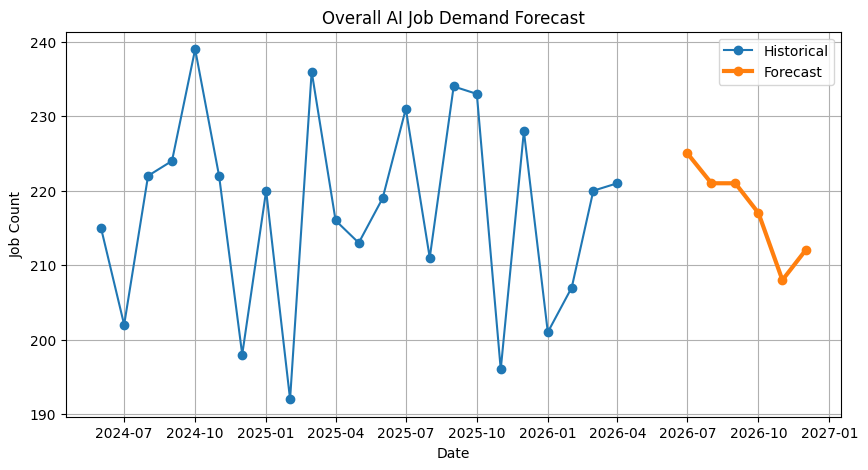

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_jobs["Date_Posted"],
    monthly_jobs["Job_Count"],
    marker="o",
    label="Historical"
)

plt.plot(
    future_forecast["Date_Posted"],
    future_forecast["Job_Count"],
    marker="o",
    linewidth=3,
    label="Forecast"
)

plt.title("Overall AI Job Demand Forecast")

plt.xlabel("Date")

plt.ylabel("Job Count")

plt.grid(True)

plt.legend()

plt.show()

In [11]:
future_forecast.to_csv(
    "Job_forecast.csv",
    index=False
)

print("job_forecast.csv saved successfully!")

job_forecast.csv saved successfully!


In [12]:
# ==========================================
# Section 7 : Quarterly Forecast
# ==========================================

quarterly_forecast = future_forecast.copy()

quarterly_forecast["Quarter"] = (
    quarterly_forecast["Date_Posted"]
    .dt.to_period("Q")
    .astype(str)
)

quarterly_forecast = (
    quarterly_forecast
    .groupby("Quarter", as_index=False)["Job_Count"]
    .sum()
)

quarterly_forecast

,Quarter,Job_Count
0,2026Q3,667
1,2026Q4,637


In [13]:
quarterly_forecast.to_csv(
    "quarterly_job_forecast.csv",
    index=False
)

print("quarterly_job_forecast.csv saved successfully!")

quarterly_job_forecast.csv saved successfully!


In [14]:
# ==========================================
# Section 7 : Yearly Forecast
# ==========================================

yearly_forecast = future_forecast.copy()

yearly_forecast["Year"] = yearly_forecast["Date_Posted"].dt.year

yearly_forecast = (
    yearly_forecast
    .groupby("Year", as_index=False)["Job_Count"]
    .sum()
)

yearly_forecast

,Year,Job_Count
0,2026,1304


In [15]:
yearly_forecast.to_csv(
    "yearly_job_forecast.csv",
    index=False
)

print("yearly_job_forecast.csv saved successfully!")

yearly_job_forecast.csv saved successfully!


In [16]:
# ==========================================
# Section 8 : Job Role Forecasting
# ==========================================

top_roles = (
    df["Job_Title"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print(top_roles)

['Software Engineer', 'Backend Developer', 'Full Stack Developer', 'Data Analyst', 'Java Developer']


In [17]:
#Create forecast table
future_dates = pd.date_range(
    start="2026-07-01",
    periods=6,
    freq="MS"
)

job_role_forecast = pd.DataFrame({
    "Date": future_dates
})

In [18]:
#Forecast each jobrole

for role in top_roles:

    print(f"Forecasting {role}...")

    temp = df[df["Job_Title"] == role].copy()

    monthly = (
        temp.groupby(
            pd.Grouper(key="Date_Posted", freq="MS")
        )
        .size()
        .reset_index(name="Job_Count")
    )

    # Time Features
    monthly["Year"] = monthly["Date_Posted"].dt.year
    monthly["Month"] = monthly["Date_Posted"].dt.month
    monthly["Quarter"] = monthly["Date_Posted"].dt.quarter

    # Lag Features
    monthly["Lag1"] = monthly["Job_Count"].shift(1)

    monthly["RollingMean"] = (
        monthly["Job_Count"]
        .rolling(3)
        .mean()
    )

    monthly = monthly.dropna()

    features = [
        "Year",
        "Month",
        "Quarter",
        "Lag1",
        "RollingMean"
    ]

    X = monthly[features]
    y = monthly["Job_Count"]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X, y)

    history = monthly.copy()

    predictions = []

    for date in future_dates:

        lag = history.iloc[-1]["Job_Count"]

        rolling = history["Job_Count"].tail(3).mean()

        row = pd.DataFrame({
            "Year":[date.year],
            "Month":[date.month],
            "Quarter":[date.quarter],
            "Lag1":[lag],
            "RollingMean":[rolling]
        })

        pred = model.predict(row)[0]

        pred = max(round(pred),0)

        predictions.append(pred)

        history = pd.concat([
            history,
            pd.DataFrame({
                "Date_Posted":[date],
                "Job_Count":[pred]
            })
        ], ignore_index=True)

    job_role_forecast[role] = predictions

Forecasting Software Engineer...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:364: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\

Forecasting Backend Developer...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:364: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\

Forecasting Full Stack Developer...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting Data Analyst...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting Java Developer...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

In [19]:
job_role_forecast

,Date,Software Engineer,Backend Developer,Full Stack Developer,Data Analyst,Java Developer
0,2026-07-01,18,12,8,15,10
1,2026-08-01,16,17,11,12,10
2,2026-09-01,17,17,9,10,10
3,2026-10-01,18,14,8,14,13
4,2026-11-01,17,18,9,13,9
5,2026-12-01,16,18,6,12,13


In [20]:
job_role_forecast.to_csv(
    "job_role_forecast.csv",
    index=False
)

print("job_role_forecast.csv saved successfully!")

job_role_forecast.csv saved successfully!


In [21]:
#Quarterly
job_role_quarterly = job_role_forecast.copy()

job_role_quarterly["Quarter"] = (
    pd.to_datetime(job_role_quarterly["Date"])
    .dt.to_period("Q")
    .astype(str)
)

job_role_quarterly = (
    job_role_quarterly
    .groupby("Quarter")
    .sum(numeric_only=True)
    .reset_index()
)

job_role_quarterly

,Quarter,Software Engineer,Backend Developer,Full Stack Developer,Data Analyst,Java Developer
0,2026Q3,51,46,28,37,30
1,2026Q4,51,50,23,39,35


In [22]:
job_role_quarterly.to_csv(
    "job_role_forecast_quarterly.csv",
    index=False
)

In [23]:
#yearly
job_role_yearly = job_role_forecast.copy()

job_role_yearly["Year"] = (
    pd.to_datetime(job_role_yearly["Date"])
    .dt.year
)

job_role_yearly = (
    job_role_yearly
    .groupby("Year")
    .sum(numeric_only=True)
    .reset_index()
)

job_role_yearly

,Year,Software Engineer,Backend Developer,Full Stack Developer,Data Analyst,Java Developer
0,2026,102,96,51,76,65


In [24]:
job_role_yearly.to_csv(
    "job_role_forecast_yearly.csv",
    index=False
)

print("Job role forecasting completed successfully!")

Job role forecasting completed successfully!


In [25]:
# ==========================================
# Section 9 : Top Skills Forecast
# ==========================================

# Split skills into individual rows
skills_df = (
    df.assign(
        Skill=df["Skills_Required"].str.split(",")
    )
    .explode("Skill")
)

skills_df["Skill"] = skills_df["Skill"].str.strip()

# Top 5 Skills
top_skills = (
    skills_df["Skill"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print(top_skills)

['Python', 'REST APIs', 'AWS', 'SQL', 'Docker']


In [26]:
future_dates = pd.date_range(
    start="2026-07-01",
    periods=6,
    freq="MS"
)

skills_forecast = pd.DataFrame({
    "Date": future_dates
})

In [27]:
from xgboost import XGBRegressor

for skill in top_skills:

    print(f"Forecasting {skill}...")

    temp = skills_df[
        skills_df["Skill"].str.lower() == skill.lower()
    ].copy()

    monthly = (
        temp.groupby(
            pd.Grouper(key="Date_Posted", freq="MS")
        )
        .size()
        .reset_index(name="Job_Count")
    )

    # Time Features
    monthly["Year"] = monthly["Date_Posted"].dt.year
    monthly["Month"] = monthly["Date_Posted"].dt.month
    monthly["Quarter"] = monthly["Date_Posted"].dt.quarter

    # Lag Features
    monthly["Lag1"] = monthly["Job_Count"].shift(1)

    monthly["RollingMean"] = (
        monthly["Job_Count"]
        .rolling(3)
        .mean()
    )

    monthly = monthly.dropna()

    features = [
        "Year",
        "Month",
        "Quarter",
        "Lag1",
        "RollingMean"
    ]

    X = monthly[features]
    y = monthly["Job_Count"]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X, y)

    history = monthly.copy()

    predictions = []

    for date in future_dates:

        lag = history.iloc[-1]["Job_Count"]

        rolling = history["Job_Count"].tail(3).mean()

        row = pd.DataFrame({
            "Year":[date.year],
            "Month":[date.month],
            "Quarter":[date.quarter],
            "Lag1":[lag],
            "RollingMean":[rolling]
        })

        pred = model.predict(row)[0]

        pred = round(max(pred,0))

        predictions.append(pred)

        history = pd.concat([
            history,
            pd.DataFrame({
                "Date_Posted":[date],
                "Job_Count":[pred]
            })
        ], ignore_index=True)

    skills_forecast[skill] = predictions

Forecasting Python...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:364: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\

Forecasting REST APIs...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting AWS...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting SQL...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting Docker...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

In [29]:
skills_forecast.to_csv(
    "top_skills_forecast.csv",
    index=False
)

print("top_skills_forecast.csv saved successfully!")

top_skills_forecast.csv saved successfully!


In [31]:
skills_quarterly = skills_forecast.copy()

skills_quarterly["Quarter"] = (
    pd.to_datetime(skills_quarterly["Date"])
    .dt.to_period("Q")
    .astype(str)
)

skills_quarterly = (
    skills_quarterly
    .groupby("Quarter")
    .sum(numeric_only=True)
    .reset_index()
)

skills_quarterly.to_csv(
    "top_skills_forecast_quarterly.csv",
    index=False
)

print("top_skills_forecast_quarterly.csv saved successfully!")

top_skills_forecast_quarterly.csv saved successfully!


In [34]:
skills_yearly = skills_forecast.copy()

skills_yearly["Year"] = (
    pd.to_datetime(skills_yearly["Date"])
    .dt.year
)

skills_yearly = (
    skills_yearly
    .groupby("Year")
    .sum(numeric_only=True)
    .reset_index()
)

skills_yearly.to_csv(
    "top_skills_forecast_yearly.csv",
    index=False
)

print("Top Skills Forecast completed successfully!")

Top Skills Forecast completed successfully!


In [35]:
# ==========================================
# Section 10 : Emerging AI Skills Forecast
# ==========================================

emerging_skills = [
    "OpenAI API",
    "LangChain",
    "RAG",
    "HuggingFace",
    "Transformers"
]

print(emerging_skills)

['OpenAI API', 'LangChain', 'RAG', 'HuggingFace', 'Transformers']


In [36]:
future_dates = pd.date_range(
    start="2026-07-01",
    periods=6,
    freq="MS"
)

emerging_forecast = pd.DataFrame({
    "Date": future_dates
})

In [37]:
from xgboost import XGBRegressor

for skill in emerging_skills:

    print(f"Forecasting {skill}...")

    temp = skills_df[
        skills_df["Skill"].str.lower() == skill.lower()
    ].copy()

    monthly = (
        temp.groupby(
            pd.Grouper(key="Date_Posted", freq="MS")
        )
        .size()
        .reset_index(name="Job_Count")
    )

    # Skip if insufficient data
    if len(monthly) < 6:
        print(f"Skipping {skill} (insufficient historical data)")
        continue

    # ----------------------
    # Feature Engineering
    # ----------------------

    monthly["Year"] = monthly["Date_Posted"].dt.year
    monthly["Month"] = monthly["Date_Posted"].dt.month
    monthly["Quarter"] = monthly["Date_Posted"].dt.quarter

    monthly["Lag1"] = monthly["Job_Count"].shift(1)

    monthly["RollingMean"] = (
        monthly["Job_Count"]
        .rolling(3)
        .mean()
    )

    monthly = monthly.dropna()

    features = [
        "Year",
        "Month",
        "Quarter",
        "Lag1",
        "RollingMean"
    ]

    X = monthly[features]
    y = monthly["Job_Count"]

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X, y)

    history = monthly.copy()

    predictions = []

    for date in future_dates:

        lag = history.iloc[-1]["Job_Count"]

        rolling = history["Job_Count"].tail(3).mean()

        row = pd.DataFrame({
            "Year":[date.year],
            "Month":[date.month],
            "Quarter":[date.quarter],
            "Lag1":[lag],
            "RollingMean":[rolling]
        })

        pred = model.predict(row)[0]

        pred = round(max(pred,0))

        predictions.append(pred)

        history = pd.concat([
            history,
            pd.DataFrame({
                "Date_Posted":[date],
                "Job_Count":[pred]
            })
        ], ignore_index=True)

    emerging_forecast[skill] = predictions

Forecasting OpenAI API...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:364: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\

Forecasting LangChain...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting RAG...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting HuggingFace...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

Forecasting Transformers...


C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_d

In [38]:
emerging_forecast

,Date,OpenAI API,LangChain,RAG,HuggingFace,Transformers
0,2026-07-01,3,4,4,7,3
1,2026-08-01,3,4,2,7,3
2,2026-09-01,3,3,3,6,1
3,2026-10-01,3,5,3,5,2
4,2026-11-01,4,5,2,6,3
5,2026-12-01,2,3,3,6,2


In [39]:
emerging_forecast.to_csv(
    "emerging_skills_forecast.csv",
    index=False
)

print("emerging_skills_forecast.csv saved successfully!")

emerging_skills_forecast.csv saved successfully!


In [41]:
emerging_quarterly = emerging_forecast.copy()

emerging_quarterly["Quarter"] = (
    pd.to_datetime(emerging_quarterly["Date"])
    .dt.to_period("Q")
    .astype(str)
)

emerging_quarterly = (
    emerging_quarterly
    .groupby("Quarter")
    .sum(numeric_only=True)
    .reset_index()
)

emerging_quarterly.to_csv(
    "emerging_skills_forecast_quarterly.csv",
    index=False
)

print("emerging_skills_forecast_quarterly.csv saved successfully!")

emerging_skills_forecast_quarterly.csv saved successfully!


In [43]:
emerging_yearly = emerging_forecast.copy()

emerging_yearly["Year"] = (
    pd.to_datetime(emerging_yearly["Date"])
    .dt.year
)

emerging_yearly = (
    emerging_yearly
    .groupby("Year")
    .sum(numeric_only=True)
    .reset_index()
)

emerging_yearly.to_csv(
    "emerging_skills_forecast_yearly.csv",
    index=False
)

print("Emerging Skills Forecast completed successfully!")

Emerging Skills Forecast completed successfully!
